# Deep Scientific Validation: eos1suh (BioSynFoni)

This notebook validates that the BioSynFoni biosynthesis-informed fingerprint model produces **scientifically meaningful** results, beyond just running correctly.

**Three validation layers:**
1. **Distribution Analysis** — Run 50 diverse molecules, check output statistics
2. **Sanity Checks** — Verify structurally similar molecules get similar fingerprints
3. **Paper Reproduction** — Validate the paper's claim that BioSynFoni captures biosynthetic origin

## Setup

In [1]:
# Install dependencies if needed (uncomment to run)
# !pip install biosynfoni==1.0.0 rdkit numpy tqdm matplotlib seaborn pandas

In [2]:
import os
import csv
import math
import time
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from biosynfoni import Biosynfoni
from biosynfoni.subkeys import fpVersions
from rdkit import Chem

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

# Get column names from the default version
COLUMN_NAMES = fpVersions["full_1103"]

# Model paths
MODEL_DIR = Path(".").resolve()
MAIN_PY = MODEL_DIR / "model" / "framework" / "code" / "main.py"
COLUMNS_CSV = MODEL_DIR / "model" / "framework" / "columns" / "run_columns.csv"
METADATA_YML = MODEL_DIR / "metadata.yml"

print(f"Model directory: {MODEL_DIR}")
print(f"main.py exists: {MAIN_PY.exists()}")
print(f"Fingerprint dimensions: {len(COLUMN_NAMES)}")

Model directory: /Users/tensor/dev/ersilia-os/ersilia/eos1suh
main.py exists: True
Fingerprint dimensions: 39


In [3]:
def run_model(smiles_list):
    """Run BioSynFoni fingerprint on a list of SMILES, return DataFrame and elapsed time."""
    t0 = time.time()
    outputs = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            outputs.append([0] * len(COLUMN_NAMES))
        else:
            fp = Biosynfoni(mol).fingerprint
            outputs.append(fp)
    elapsed = time.time() - t0
    
    df = pd.DataFrame(outputs, columns=COLUMN_NAMES)
    return df, elapsed


def cosine_similarity(a, b):
    """Compute cosine similarity between two vectors."""
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    dot = np.dot(a, b)
    norm_a, norm_b = np.linalg.norm(a), np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot / (norm_a * norm_b)


print("Helper functions ready.")

Helper functions ready.


---
## 1. Distribution Analysis

Run the model on **50 diverse molecules** spanning different chemical families and analyze the output distribution across all 39 fingerprint dimensions.

In [4]:
DIVERSE_50 = [
    "CC(=O)Oc1ccccc1C(=O)O",                          # aspirin
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",                     # ibuprofen
    "Cn1c(=O)c2c(ncn2C)n(c1=O)C",                     # caffeine
    "CC(=O)Nc1ccc(O)cc1",                              # acetaminophen
    "OC(=O)c1ccccc1O",                                 # salicylic acid
    "c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34",                # pyrene
    "O=C(O)C(N)Cc1ccccc1",                             # phenylalanine
    "CC12CCC3C(CCC4CC(=O)CCC34C)C1CCC2O",             # testosterone
    "CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21",            # diazepam
    "CC(CS)C(=O)N1CCCC1C(=O)O",                       # captopril
    "Clc1ccc(cc1)C(c1ccc(Cl)cc1)C(Cl)(Cl)Cl",        # DDT
    "CC(C)NCC(O)c1ccc(O)c(O)c1",                      # isoprenaline
    "OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",       # glucose
    "c1ccc(cc1)-c1ccccc1",                             # biphenyl
    "NCCc1c[nH]c2ccc(O)cc12",                         # serotonin
    "CC(C)(C)NCC(O)c1ccc(O)c(CO)c1",                  # salbutamol
    "OC(=O)c1cc(O)c(O)c(O)c1",                        # gallic acid
    "O=c1[nH]c(=O)c2[nH]cnc2[nH]1",                  # uric acid
    "FC(F)(F)c1ccc(cc1)S(=O)(=O)N",                   # trifluoromethylbenzenesulfonamide
    "CC1=CC(=O)c2c(O)cccc2C1=O",                      # plumbagin
    "c1ccc(-c2ccccn2)nc1",                             # bipyridine
    "O=C(O)CCCCCCCCCCCCCCC",                           # palmitic acid
    "CCCCCCCCCCCCCCCCCCCC",                            # eicosane
    "c1ccc2[nH]ccc2c1",                               # indole
    "O=Cc1ccc(O)c(OC)c1",                             # vanillin
    "Nc1ccc(N)cc1",                                    # p-phenylenediamine
    "ClC(Cl)=C(Cl)Cl",                                # tetrachloroethylene
    "O=C(O)c1ccc(N)cc1",                              # 4-aminobenzoic acid
    "CCOC(=O)c1ccccc1N",                              # benzocaine
    "O=S(=O)(c1ccccc1)c1ccccc1",                      # diphenylsulfone
    "c1ccncc1",                                        # pyridine
    "c1cc[nH]c1",                                      # pyrrole
    "c1ccoc1",                                         # furan
    "c1ccsc1",                                         # thiophene
    "NCCCCN",                                          # putrescine
    "OC(=O)C=CC(=O)O",                                # fumaric acid
    "CC(=O)NCCC1=CNC2=C1C=C(OC)C=C2",                # melatonin
    "O=C(O)c1cccnc1",                                 # nicotinic acid
    "CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O",   # penicillin G
    "OC1C(O)C(O)C(O)C(O)C1O",                        # inositol
    "Nc1ncnc2[nH]cnc12",                              # adenine
    "NCC(=O)O",                                        # glycine
    "O=C(O)C(N)CC(=O)O",                              # aspartate
    "OC(=O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",   # ciprofloxacin
    "ClC(Cl)(Cl)Cl",                                   # carbon tetrachloride
    "O",                                               # water
    "CC(O)CC(=O)c1ccccc1",                            # benzoylacetone
    "CC(=O)c1ccc(cc1)S(C)(=O)=O",                    # methylsulfonylphenone
    "O=C(O)C(O)C(O)C(=O)O",                          # tartaric acid
    "c1ccc(cc1)-c1ccc(cc1)-c1ccccc1",                 # terphenyl
]

DIVERSE_NAMES = [
    "aspirin", "ibuprofen", "caffeine", "acetaminophen", "salicylic acid",
    "pyrene", "phenylalanine", "testosterone", "diazepam", "captopril",
    "DDT", "isoprenaline", "glucose", "biphenyl", "serotonin",
    "salbutamol", "gallic acid", "uric acid", "trifluoromethylbenzenesulfonamide", "plumbagin",
    "bipyridine", "palmitic acid", "eicosane", "indole", "vanillin",
    "p-phenylenediamine", "tetrachloroethylene", "4-aminobenzoic acid", "benzocaine", "diphenylsulfone",
    "pyridine", "pyrrole", "furan", "thiophene", "putrescine",
    "fumaric acid", "melatonin", "nicotinic acid", "penicillin G", "inositol",
    "adenine", "glycine", "aspartate", "ciprofloxacin", "carbon tetrachloride",
    "water", "benzoylacetone", "methylsulfonylphenone", "tartaric acid", "terphenyl"
]

print(f"Running model on {len(DIVERSE_50)} diverse molecules...")
df_diverse, runtime = run_model(DIVERSE_50)
print(f"Done in {runtime:.2f}s")
print(f"Output shape: {df_diverse.shape}")
df_diverse.index = DIVERSE_NAMES
df_diverse.head(10)

Running model on 50 diverse molecules...
Done in 0.02s
Output shape: (50, 39)


,co_coa,co_nadh,co_nadph,allstnd_aminos,nonstnd_aminos,s_openpyr_C6O6,s_openfur_C5O5,s_pyranose_C5O4,s_furanose_C4O3,d_indoleC2N_12,...,o_ether_1,o_hydroxyl_1,r_c3,r_c4,r_c5,r_c6,r_c7,r_c8,r_c9,r_c10
aspirin,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
ibuprofen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
caffeine,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
acetaminophen,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
salicylic acid,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
pyrene,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,5,0,0,0,6
phenylalanine,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
testosterone,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,3,0,0,1,2
diazepam,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
captopril,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 1a. Completion & Basic Stats

In [5]:
num_valid = df_diverse.notna().all(axis=1).sum()
num_total = len(df_diverse)
completion_rate = num_valid / num_total

stats = pd.DataFrame({
    "mean": df_diverse.mean(),
    "std": df_diverse.std(),
    "min": df_diverse.min(),
    "max": df_diverse.max(),
    "nonzero_count": (df_diverse != 0).sum(),
    "is_constant": df_diverse.std() == 0,
})
stats["cv"] = np.where(stats["mean"] != 0, stats["std"] / stats["mean"], 0)

n_varying = (~stats["is_constant"]).sum()
n_constant = stats["is_constant"].sum()
pct_varying = n_varying / len(stats) * 100

print(f"Completion rate:  {num_valid}/{num_total} ({completion_rate:.0%})")
print(f"Runtime:          {runtime:.2f}s")
print(f"Varying columns:  {n_varying}/{len(stats)} ({pct_varying:.0f}%)")
print(f"Constant columns: {n_constant}/{len(stats)}")
print()

# Pass/fail
status = "PASS" if pct_varying > 50 else ("WARNING" if pct_varying > 10 else "FAIL")
print(f"Distribution status: {status}")
print()

# Show constant columns
if n_constant > 0:
    print("Constant columns (always 0 across all 50 molecules):")
    for col in stats[stats["is_constant"]].index:
        print(f"  - {col}")

Completion rate:  50/50 (100%)
Runtime:          0.02s
Varying columns:  27/39 (69%)
Constant columns: 12/39

Distribution status: PASS

Constant columns (always 0 across all 50 molecules):
  - co_coa
  - co_nadh
  - co_nadph
  - nonstnd_aminos
  - s_furanose_C4O3
  - phosphate_2
  - hal_br
  - hal_i
  - o_epoxy_1
  - r_c4
  - r_c7
  - r_c8


### 1b. Fingerprint Heatmap

Visualize the 50 x 39 fingerprint matrix. Each row is a molecule, each column is a biosynthetic building block count.

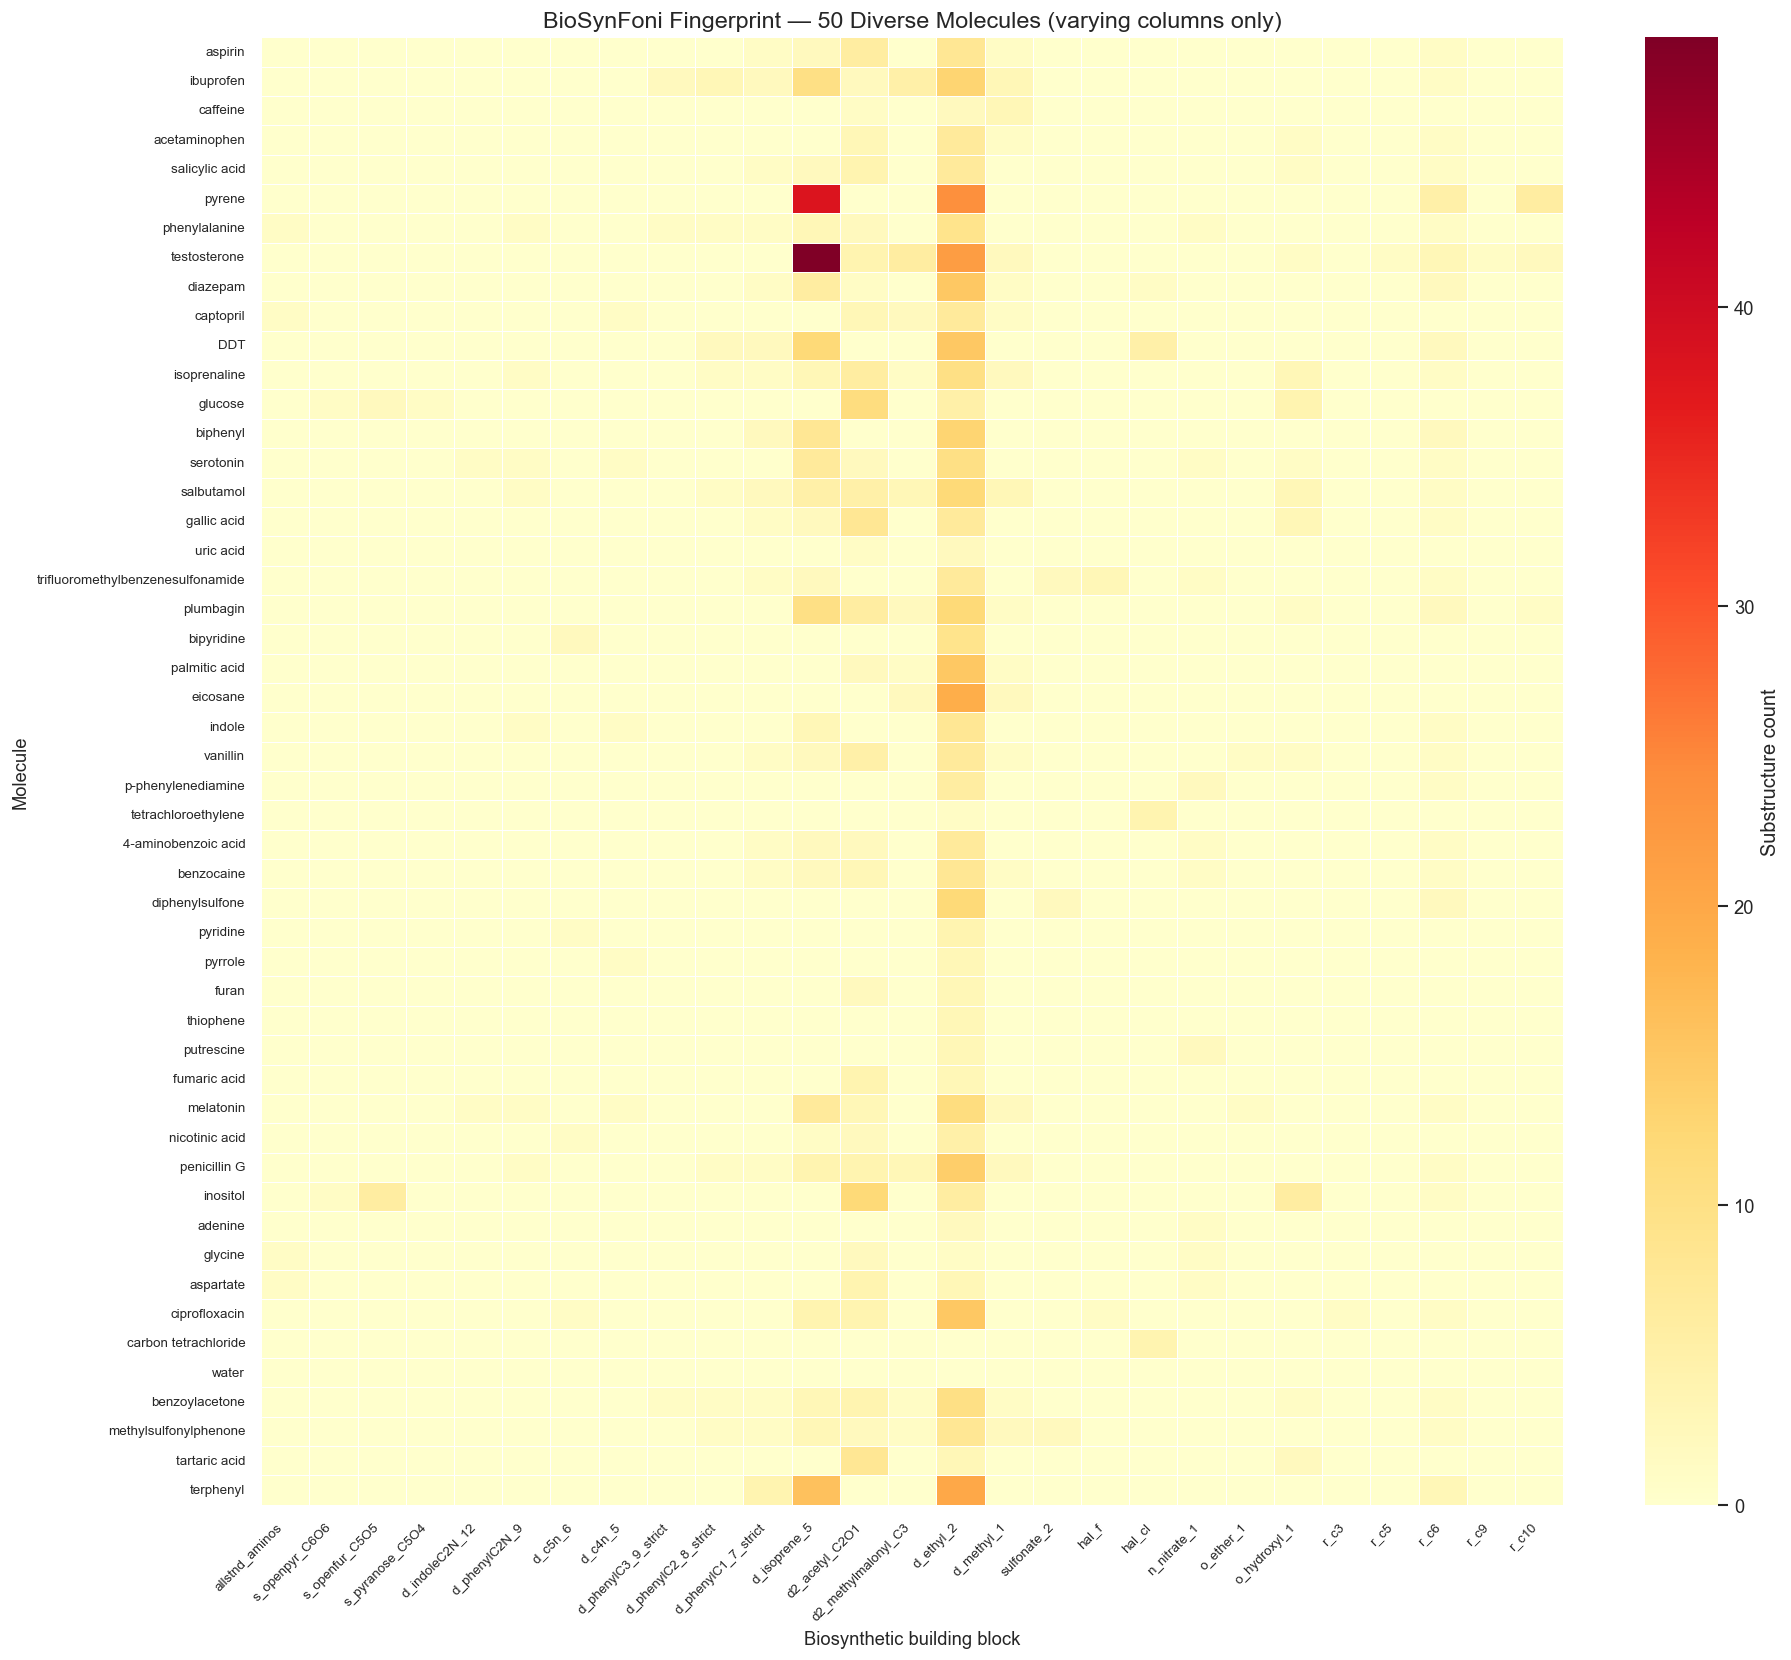

In [6]:
# Filter to varying columns only for cleaner visualization
varying_cols = stats[~stats["is_constant"]].index.tolist()
df_plot = df_diverse[varying_cols]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    df_plot, 
    cmap="YlOrRd", 
    linewidths=0.3, 
    linecolor="white",
    xticklabels=True, 
    yticklabels=True,
    ax=ax,
    cbar_kws={"label": "Substructure count"}
)
ax.set_title("BioSynFoni Fingerprint — 50 Diverse Molecules (varying columns only)", fontsize=14)
ax.set_xlabel("Biosynthetic building block", fontsize=11)
ax.set_ylabel("Molecule", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### 1c. Per-Column Distribution

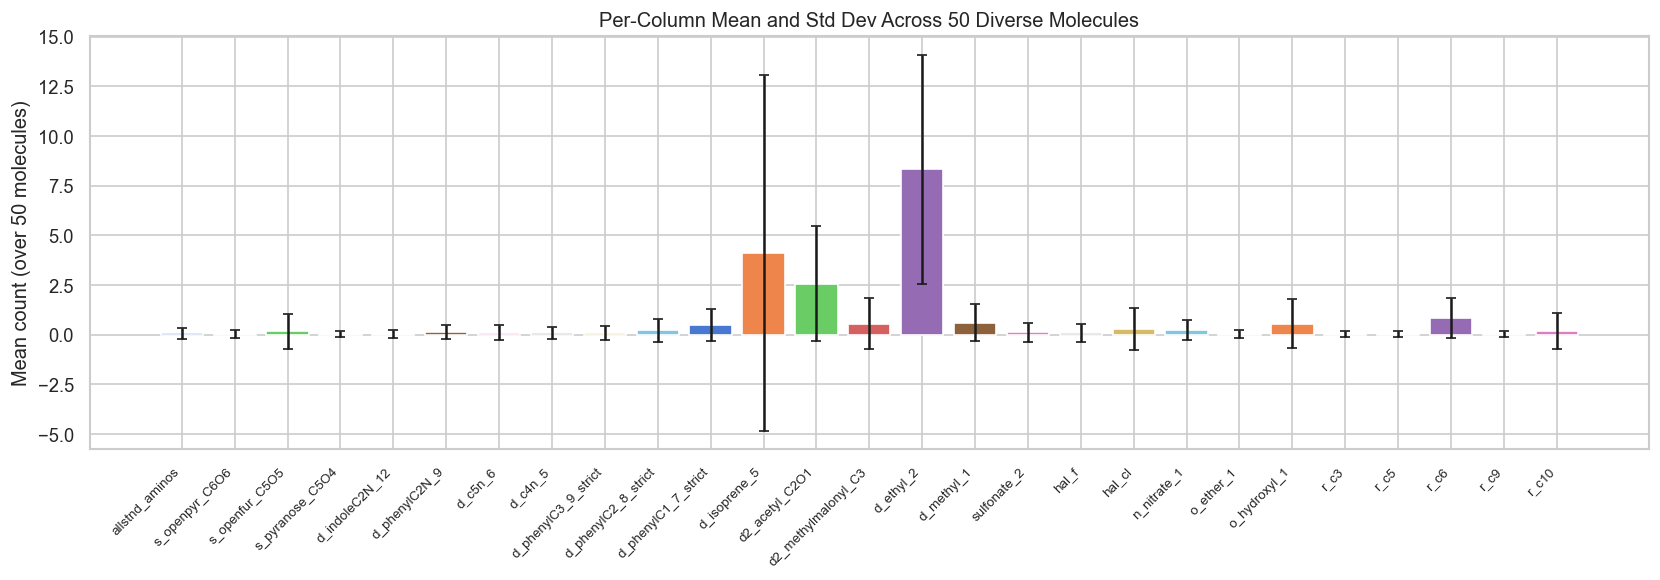

In [7]:
# Bar chart of mean +/- std for each varying column
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(varying_cols))
means = [stats.loc[c, "mean"] for c in varying_cols]
stds = [stats.loc[c, "std"] for c in varying_cols]

ax.bar(x, means, yerr=stds, capsize=3, color=sns.color_palette("muted"), edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(varying_cols, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean count (over 50 molecules)")
ax.set_title("Per-Column Mean and Std Dev Across 50 Diverse Molecules")
plt.tight_layout()
plt.show()

### 1d. Pairwise Similarity Distribution

Pairwise similarities: 1225 pairs
Mean: 0.6722
Std:  0.2830
Min:  0.0000
Max:  0.9997


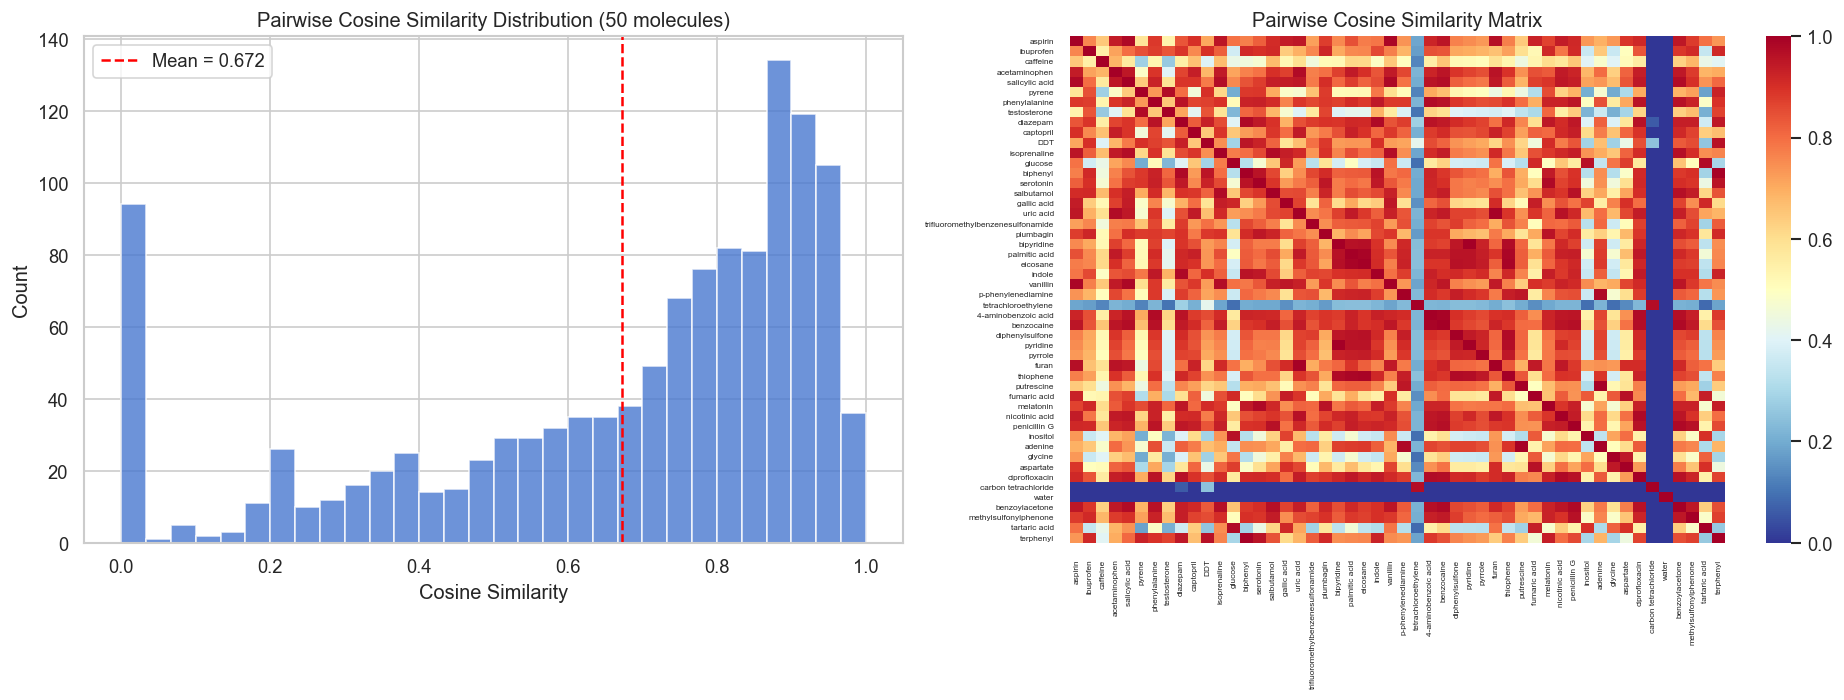

In [8]:
# Compute all pairwise cosine similarities
vectors = df_diverse.values.astype(float)
n = len(vectors)
similarities = []
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        s = cosine_similarity(vectors[i], vectors[j])
        similarities.append(s)
        sim_matrix[i][j] = s
        sim_matrix[j][i] = s
    sim_matrix[i][i] = 1.0

print(f"Pairwise similarities: {len(similarities)} pairs")
print(f"Mean: {np.mean(similarities):.4f}")
print(f"Std:  {np.std(similarities):.4f}")
print(f"Min:  {np.min(similarities):.4f}")
print(f"Max:  {np.max(similarities):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(similarities, bins=30, color=sns.color_palette("muted")[0], edgecolor="white", alpha=0.8)
axes[0].axvline(np.mean(similarities), color="red", linestyle="--", label=f"Mean = {np.mean(similarities):.3f}")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Pairwise Cosine Similarity Distribution (50 molecules)")
axes[0].legend()

# Heatmap
sns.heatmap(
    sim_matrix, 
    cmap="RdYlBu_r", 
    vmin=0, vmax=1,
    xticklabels=DIVERSE_NAMES, 
    yticklabels=DIVERSE_NAMES,
    ax=axes[1]
)
axes[1].set_title("Pairwise Cosine Similarity Matrix")
plt.xticks(fontsize=5, rotation=90)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()

---
## 2. Sanity Checks (Fingerprint Similarity)

Since BioSynFoni is tagged as a **Fingerprint** model, we test that:
- Structurally **similar** molecules (aspirin / salicylic acid) produce **high** cosine similarity
- Structurally **dissimilar** molecules (eicosane / adenine) produce **low** cosine similarity

In [9]:
# Run model on sanity check compounds
sanity_smiles = [
    "CC(=O)Oc1ccccc1C(=O)O",   # aspirin
    "OC(=O)c1ccccc1O",          # salicylic acid
    "CCCCCCCCCCCCCCCCCCCC",      # eicosane
    "Nc1ncnc2[nH]cnc12",        # adenine
]
sanity_names = ["aspirin", "salicylic_acid", "eicosane", "adenine"]

df_sanity, _ = run_model(sanity_smiles)
df_sanity.index = sanity_names

sim_similar = cosine_similarity(df_sanity.loc["aspirin"].values, df_sanity.loc["salicylic_acid"].values)
sim_dissimilar = cosine_similarity(df_sanity.loc["eicosane"].values, df_sanity.loc["adenine"].values)

print("=" * 60)
print("SANITY CHECK: Fingerprint Similarity")
print("=" * 60)
print(f"\nSimilar pair (aspirin / salicylic acid):   {sim_similar:.4f}")
print(f"Dissimilar pair (eicosane / adenine):       {sim_dissimilar:.4f}")
print(f"\nSeparation: {sim_similar - sim_dissimilar:.4f}")
print(f"Ratio:      {sim_similar / sim_dissimilar:.4f}x")
print(f"\nResult:     {'PASS' if sim_similar > sim_dissimilar else 'FAIL'}")

SANITY CHECK: Fingerprint Similarity

Similar pair (aspirin / salicylic acid):   0.9798
Dissimilar pair (eicosane / adenine):       0.8847

Separation: 0.0951
Ratio:      1.1075x

Result:     PASS


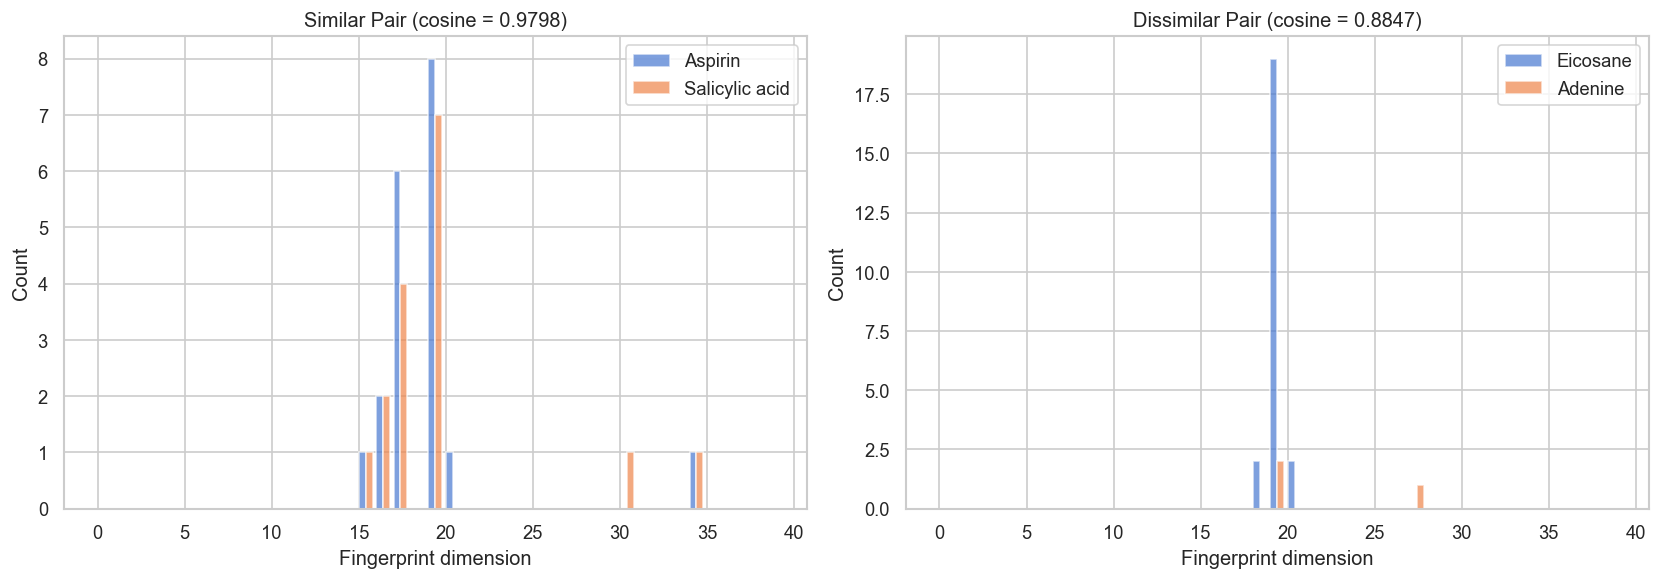

In [10]:
# Visual comparison of the two pairs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Similar pair
x = range(len(df_sanity.columns))
axes[0].bar(x, df_sanity.loc["aspirin"].values, alpha=0.7, label="Aspirin", width=0.4, align="edge")
axes[0].bar([i + 0.4 for i in x], df_sanity.loc["salicylic_acid"].values, alpha=0.7, label="Salicylic acid", width=0.4, align="edge")
axes[0].set_title(f"Similar Pair (cosine = {sim_similar:.4f})", fontsize=12)
axes[0].set_xlabel("Fingerprint dimension")
axes[0].set_ylabel("Count")
axes[0].legend()

# Dissimilar pair
axes[1].bar(x, df_sanity.loc["eicosane"].values, alpha=0.7, label="Eicosane", width=0.4, align="edge")
axes[1].bar([i + 0.4 for i in x], df_sanity.loc["adenine"].values, alpha=0.7, label="Adenine", width=0.4, align="edge")
axes[1].set_title(f"Dissimilar Pair (cosine = {sim_dissimilar:.4f})", fontsize=12)
axes[1].set_xlabel("Fingerprint dimension")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Paper Reproduction

**Paper claim:** BioSynFoni captures biosynthetic origin — molecules from the same biosynthetic class should have more similar fingerprints than molecules from different classes.

**Method:** Compute within-class vs between-class cosine similarity using 23 known natural products across 6 biosynthetic classes (alkaloid, isoprenoid, phenylpropanoid, carbohydrate, fatty acid, polyketide).

In [11]:
# Natural products organized by biosynthetic class
# Each tuple: (SMILES, common_name)
BIOSYNTHETIC_CLASSES = {
    "alkaloid": [
        ("CN1CCC23C4OC5=C(O)C=CC(=C25)C(C1CC34O)=O", "oxycodone"),
        ("CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2", "atropine"),
        ("CCN(CC)C(=O)C1CN(C)C2CC3=CNC4=CC=CC(=C34)C2=C1", "LSD"),
        ("c1ccc2c(c1)c1ccncc1[nH]2", "beta-carboline"),
    ],
    "isoprenoid": [
        ("CC1=CCC(CC1)C(=C)C", "limonene"),
        ("CC(=CCCC(C)=CCCC(C)=CCO)C", "farnesol"),
        ("CC1=C2CC(CC1)C2(C)C", "alpha-pinene"),
        ("CC(=O)OC1CC(C)(C)C2CCC3(C)C(CCC4C5(C)CCC(=O)C(C)(C)C5CCC43C2C1C)C", "betulin_acetate"),
    ],
    "phenylpropanoid": [
        ("OC(=O)/C=C/c1ccc(O)cc1", "p-coumaric acid"),
        ("COc1cc(/C=C/C(=O)O)ccc1O", "ferulic acid"),
        ("OC(=O)/C=C/c1ccc(O)c(O)c1", "caffeic acid"),
        ("O=C(/C=C/c1ccc(O)c(O)c1)OC1CC(O)(C(=O)O)CC(O)C1O", "chlorogenic acid"),
    ],
    "carbohydrate": [
        ("OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O", "D-glucose"),
        ("OC[C@H]1OC(O)[C@@H](O)[C@@H](O)[C@@H]1O", "D-galactose"),
        ("OC[C@H]1OC(O)[C@@H](O)[C@H](O)[C@@H]1O", "D-mannose"),
        ("CC1OC(O)C(O)C(O)C1O", "L-rhamnose"),
    ],
    "fatty_acid": [
        ("CCCCCCCCCCCCCCCC(=O)O", "palmitic acid"),
        ("CCCCCCCCCCCCCCCCCC(=O)O", "stearic acid"),
        ("CCCCCCCC/C=C\\CCCCCCCC(=O)O", "oleic acid"),
        ("CC/C=C\\C/C=C\\C/C=C\\CCCCCCCC(=O)O", "alpha-linolenic acid"),
    ],
    "polyketide": [
        ("CC(=O)c1c(O)cc(O)cc1O", "phloroacetophenone"),
        ("Oc1cc(O)c2c(c1)oc(-c1ccc(O)c(O)c1)c(O)c2=O", "quercetin"),
        ("CC1OC2CC3CC(O)(CC(=O)C3C(O)C2C1O)C(=O)O", "tetracycline_core"),
    ],
}

# Flatten all SMILES
all_smiles = []
all_labels = []
all_classes = []
for cls, compounds in BIOSYNTHETIC_CLASSES.items():
    for smi, name in compounds:
        all_smiles.append(smi)
        all_labels.append(name)
        all_classes.append(cls)

print(f"Running model on {len(all_smiles)} natural products across {len(BIOSYNTHETIC_CLASSES)} classes...")
df_bio, _ = run_model(all_smiles)
df_bio.index = all_labels
print(f"Output shape: {df_bio.shape}")
df_bio.head()

Running model on 23 natural products across 6 classes...
Output shape: (23, 39)


,co_coa,co_nadh,co_nadph,allstnd_aminos,nonstnd_aminos,s_openpyr_C6O6,s_openfur_C5O5,s_pyranose_C5O4,s_furanose_C4O3,d_indoleC2N_12,...,o_ether_1,o_hydroxyl_1,r_c3,r_c4,r_c5,r_c6,r_c7,r_c8,r_c9,r_c10
oxycodone,0,0,0,0,0,0,0,0,0,0,...,0,2,1,0,0,1,1,1,0,0
atropine,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,1,0,0,0
LSD,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,2,0,0,0,1
beta-carboline,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
limonene,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [12]:
# Compute within-class and between-class cosine similarities
within_class_sims = []
between_class_sims = []
per_class_within = defaultdict(list)

vectors_bio = df_bio.values.astype(float)
n_bio = len(vectors_bio)

for i in range(n_bio):
    for j in range(i + 1, n_bio):
        sim = cosine_similarity(vectors_bio[i], vectors_bio[j])
        if all_classes[i] == all_classes[j]:
            within_class_sims.append(sim)
            per_class_within[all_classes[i]].append(sim)
        else:
            between_class_sims.append(sim)

within_mean = np.mean(within_class_sims)
between_mean = np.mean(between_class_sims)
separation = within_mean - between_mean
ratio = within_mean / between_mean if between_mean > 0 else float("inf")

print("=" * 60)
print("PAPER REPRODUCTION: Biosynthetic Class Similarity")
print("=" * 60)
print(f"\nWithin-class similarity (mean):  {within_mean:.4f}  (n={len(within_class_sims)} pairs)")
print(f"Between-class similarity (mean): {between_mean:.4f}  (n={len(between_class_sims)} pairs)")
print(f"\nSeparation: {separation:.4f}")
print(f"Ratio:      {ratio:.4f}x")
print(f"\nPer-class within-class similarity:")
for cls in BIOSYNTHETIC_CLASSES:
    sims = per_class_within[cls]
    if sims:
        print(f"  {cls:20s}: {np.mean(sims):.4f} (n={len(sims)} pairs)")

result = "PASS" if within_mean > between_mean else "FAIL"
print(f"\nResult: {result} — within-class > between-class")

PAPER REPRODUCTION: Biosynthetic Class Similarity

Within-class similarity (mean):  0.9383  (n=33 pairs)
Between-class similarity (mean): 0.6793  (n=220 pairs)

Separation: 0.2590
Ratio:      1.3814x

Per-class within-class similarity:
  alkaloid            : 0.8933 (n=6 pairs)
  isoprenoid          : 0.8272 (n=6 pairs)
  phenylpropanoid     : 0.9670 (n=6 pairs)
  carbohydrate        : 0.9926 (n=6 pairs)
  fatty_acid          : 0.9999 (n=6 pairs)
  polyketide          : 0.9613 (n=3 pairs)

Result: PASS — within-class > between-class


/var/folders/x2/_7_8x8s53ps_byclb4102g0h0000gn/T/ipykernel_37899/2811391767.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(class_data, labels=class_labels, patch_artist=True)


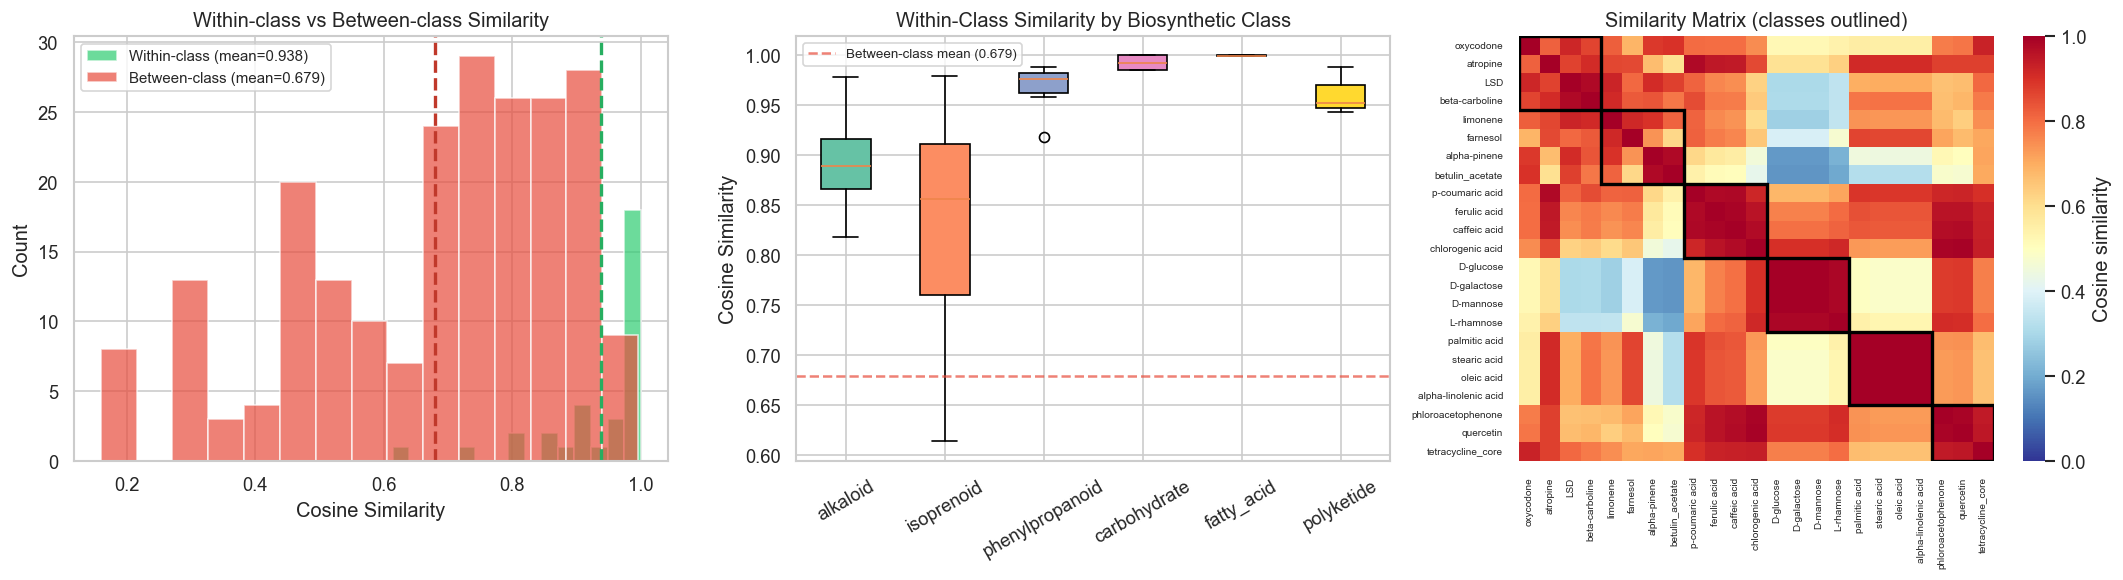

In [13]:
# Visualization: within-class vs between-class similarity distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overlaid histograms
axes[0].hist(within_class_sims, bins=15, alpha=0.7, color="#2ecc71", label=f"Within-class (mean={within_mean:.3f})", edgecolor="white")
axes[0].hist(between_class_sims, bins=15, alpha=0.7, color="#e74c3c", label=f"Between-class (mean={between_mean:.3f})", edgecolor="white")
axes[0].axvline(within_mean, color="#27ae60", linestyle="--", linewidth=2)
axes[0].axvline(between_mean, color="#c0392b", linestyle="--", linewidth=2)
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Within-class vs Between-class Similarity")
axes[0].legend(fontsize=9)

# 2. Per-class box plot
class_data = [per_class_within[cls] for cls in BIOSYNTHETIC_CLASSES if per_class_within[cls]]
class_labels = [cls for cls in BIOSYNTHETIC_CLASSES if per_class_within[cls]]
bp = axes[1].boxplot(class_data, labels=class_labels, patch_artist=True)
colors = sns.color_palette("Set2", len(class_labels))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1].axhline(between_mean, color="#e74c3c", linestyle="--", alpha=0.7, label=f"Between-class mean ({between_mean:.3f})")
axes[1].set_ylabel("Cosine Similarity")
axes[1].set_title("Within-Class Similarity by Biosynthetic Class")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(fontsize=8)

# 3. Full similarity matrix for bio compounds
bio_sim_matrix = np.zeros((n_bio, n_bio))
for i in range(n_bio):
    for j in range(n_bio):
        bio_sim_matrix[i][j] = cosine_similarity(vectors_bio[i], vectors_bio[j])

# Add class separators
sns.heatmap(bio_sim_matrix, cmap="RdYlBu_r", vmin=0, vmax=1,
            xticklabels=all_labels, yticklabels=all_labels, ax=axes[2],
            cbar_kws={"label": "Cosine similarity"})

# Draw class boundaries
offset = 0
for cls, compounds in BIOSYNTHETIC_CLASSES.items():
    n_cls = len(compounds)
    axes[2].add_patch(plt.Rectangle((offset, offset), n_cls, n_cls, fill=False, edgecolor="black", linewidth=2))
    offset += n_cls

axes[2].set_title("Similarity Matrix (classes outlined)")
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

### 3b. Per-class Fingerprint Profiles

Visualize the average fingerprint profile for each biosynthetic class to see which building blocks distinguish them.

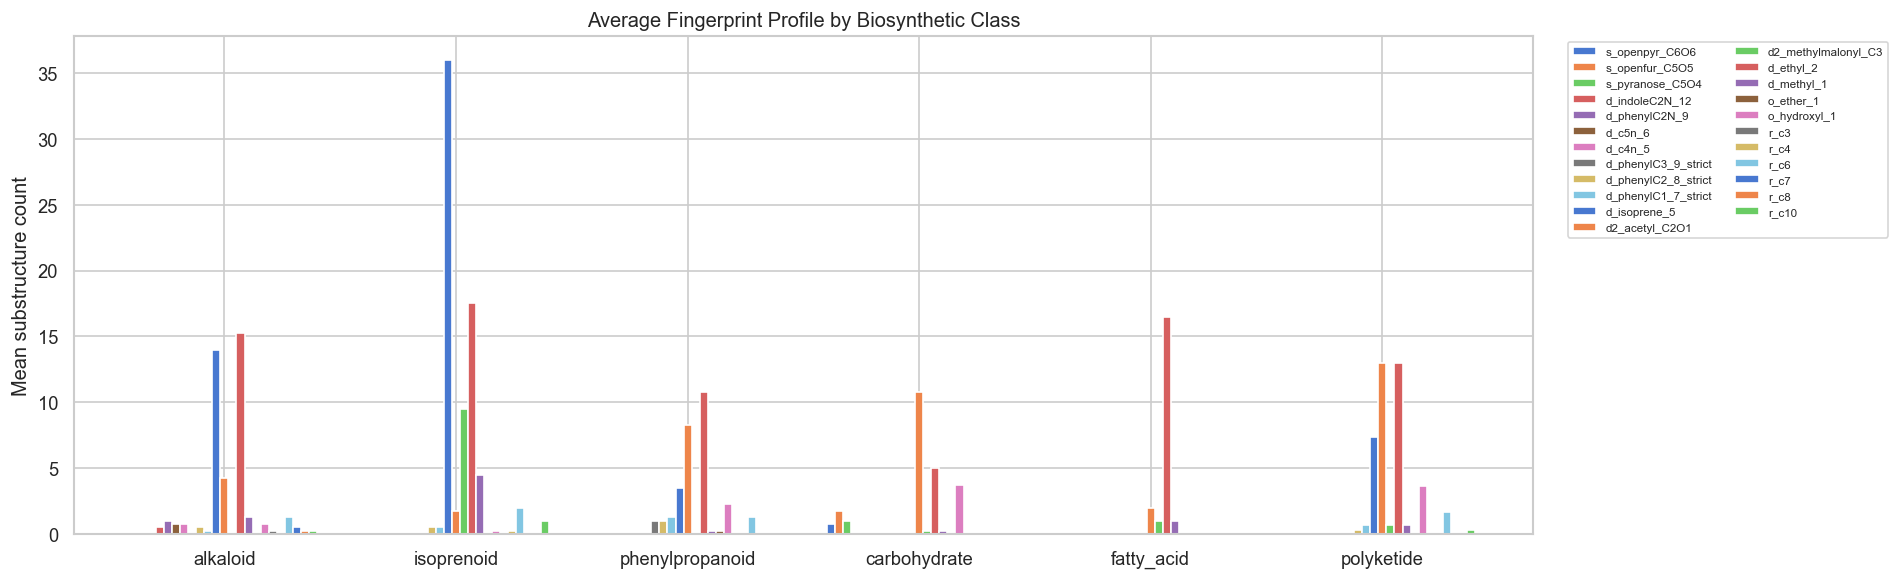

In [14]:
# Compute mean fingerprint per class
class_means = {}
offset = 0
for cls, compounds in BIOSYNTHETIC_CLASSES.items():
    n_cls = len(compounds)
    class_means[cls] = df_bio.iloc[offset:offset + n_cls].mean()
    offset += n_cls

df_class_means = pd.DataFrame(class_means).T

# Only show columns that have variation across classes
active_cols = [c for c in df_class_means.columns if df_class_means[c].max() > 0]
df_class_plot = df_class_means[active_cols]

fig, ax = plt.subplots(figsize=(16, 5))
df_class_plot.plot(kind="bar", ax=ax, width=0.8, edgecolor="white")
ax.set_ylabel("Mean substructure count")
ax.set_title("Average Fingerprint Profile by Biosynthetic Class")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

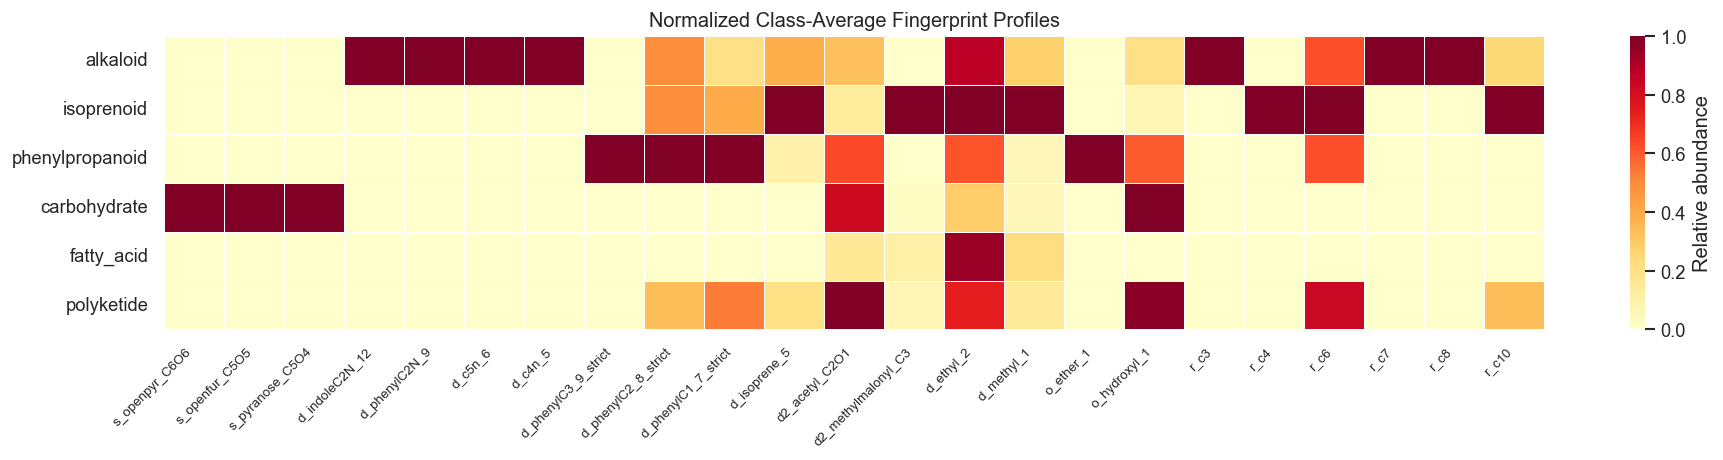


Key observations:
- Isoprenoids should show high d_isoprene_5 counts
- Carbohydrates should show sugar-related columns (s_openpyr, s_pyranose)
- Fatty acids should show high d_ethyl_2 and d2_acetyl_C2O1 counts
- Phenylpropanoids should show d_phenylC* columns
- Alkaloids should show nitrogen-containing ring features


In [15]:
# Heatmap of class-average fingerprints (normalized)
fig, ax = plt.subplots(figsize=(16, 4))
# Normalize each column by its max for visual comparison
df_norm = df_class_plot.div(df_class_plot.max() + 1e-10)
sns.heatmap(df_norm, cmap="YlOrRd", annot=False, linewidths=0.5, linecolor="white",
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={"label": "Relative abundance"})
ax.set_title("Normalized Class-Average Fingerprint Profiles")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Isoprenoids should show high d_isoprene_5 counts")
print("- Carbohydrates should show sugar-related columns (s_openpyr, s_pyranose)")
print("- Fatty acids should show high d_ethyl_2 and d2_acetyl_C2O1 counts")
print("- Phenylpropanoids should show d_phenylC* columns")
print("- Alkaloids should show nitrogen-containing ring features")

---
## 4. Summary

In [16]:
# Build summary
results = []

# Distribution
dist_status = "PASS" if pct_varying > 50 else ("WARNING" if pct_varying > 10 else "FAIL")
results.append({
    "Check": "Distribution analysis",
    "Status": dist_status,
    "Details": f"{num_valid}/{num_total} valid, {n_varying}/{len(stats)} columns vary ({pct_varying:.0f}%), runtime {runtime:.1f}s"
})

# Sanity
sanity_status = "PASS" if sim_similar > sim_dissimilar else "FAIL"
results.append({
    "Check": "Sanity (fingerprint)",
    "Status": sanity_status,
    "Details": f"Similar pair {sim_similar:.4f} > dissimilar {sim_dissimilar:.4f}"
})

# Paper reproduction
paper_status = "PASS" if within_mean > between_mean else "FAIL"
results.append({
    "Check": "Paper reproduction",
    "Status": paper_status,
    "Details": f"Within-class {within_mean:.4f} > between-class {between_mean:.4f} ({ratio:.2f}x)"
})

df_summary = pd.DataFrame(results)
print("=" * 70)
print("DEEP VALIDATION SUMMARY: eos1suh (BioSynFoni)")
print("=" * 70)
print()
print(df_summary.to_string(index=False))
print()

n_pass = sum(1 for r in results if r["Status"] == "PASS")
n_warn = sum(1 for r in results if r["Status"] == "WARNING")
n_fail = sum(1 for r in results if r["Status"] == "FAIL")
overall = "FAIL" if n_fail > 0 else ("WARNING" if n_warn > 0 else "PASS")
print(f"Overall: {overall} ({n_pass} passed, {n_warn} warnings, {n_fail} failed)")

DEEP VALIDATION SUMMARY: eos1suh (BioSynFoni)

                Check Status                                             Details
Distribution analysis   PASS 50/50 valid, 27/39 columns vary (69%), runtime 0.0s
 Sanity (fingerprint)   PASS             Similar pair 0.9798 > dissimilar 0.8847
   Paper reproduction   PASS  Within-class 0.9383 > between-class 0.6793 (1.38x)

Overall: PASS (3 passed, 0 warnings, 0 failed)


In [17]:
# Export results to JSON (same schema as test_report.json deep_checks section)
deep_checks = {
    "distribution_analysis": {
        "num_input_molecules": int(num_total),
        "runtime_seconds": round(float(runtime), 2),
        "num_valid_outputs": int(num_valid),
        "completion_rate": round(float(completion_rate), 4),
        "varying_columns": int(n_varying),
        "constant_columns": int(n_constant),
        "pct_varying": round(float(pct_varying), 1),
        "status": dist_status.lower()
    },
    "sanity_checks": {
        "matched_categories": ["fingerprint"],
        "checks": [{
            "category": "fingerprint",
            "method": "cosine_similarity",
            "similar_pair_similarity": round(float(sim_similar), 4),
            "dissimilar_pair_similarity": round(float(sim_dissimilar), 4),
            "separation_correct": bool(sim_similar > sim_dissimilar),
            "status": sanity_status.lower()
        }],
        "status": sanity_status.lower()
    },
    "paper_reproduction": {
        "status": paper_status.lower(),
        "method": "within_class_vs_between_class_cosine_similarity",
        "test_compounds": int(len(all_smiles)),
        "biosynthetic_classes": list(BIOSYNTHETIC_CLASSES.keys()),
        "within_class_similarity": round(float(within_mean), 4),
        "between_class_similarity": round(float(between_mean), 4),
        "separation_ratio": round(float(ratio), 4),
        "per_class_within_similarity": {
            cls: round(float(np.mean(sims)), 4) for cls, sims in per_class_within.items()
        }
    }
}

print(json.dumps(deep_checks, indent=2))

{
  "distribution_analysis": {
    "num_input_molecules": 50,
    "runtime_seconds": 0.02,
    "num_valid_outputs": 50,
    "completion_rate": 1.0,
    "varying_columns": 27,
    "constant_columns": 12,
    "pct_varying": 69.2,
    "status": "pass"
  },
  "sanity_checks": {
    "matched_categories": [
      "fingerprint"
    ],
    "checks": [
      {
        "category": "fingerprint",
        "method": "cosine_similarity",
        "similar_pair_similarity": 0.9798,
        "dissimilar_pair_similarity": 0.8847,
        "separation_correct": true,
        "status": "pass"
      }
    ],
    "status": "pass"
  },
  "paper_reproduction": {
    "status": "pass",
    "method": "within_class_vs_between_class_cosine_similarity",
    "test_compounds": 23,
    "biosynthetic_classes": [
      "alkaloid",
      "isoprenoid",
      "phenylpropanoid",
      "carbohydrate",
      "fatty_acid",
      "polyketide"
    ],
    "within_class_similarity": 0.9383,
    "between_class_similarity": 0.6793,
  